# 📈 Options Pricing & Simulation Engine
**Author:** [Noppijit Payab] | **Date:** [25/05/2026]

โปรเจกต์นี้เป็นการพัฒนาระบบคำนวณราคาและประเมินความเสี่ยงของ European Options โดยใช้ทฤษฎีทางคณิตศาสตร์การเงิน 2 วิธีหลัก ได้แก่:
1. **Analytical Approach:** คำนวณราคาทฤษฎีและ Option Greeks ด้วยโมเดล Black-Scholes-Merton
2. **Numerical Approach:** จำลองเส้นทางราคาสินทรัพย์ในอนาคตด้วย Geometric Brownian Motion (GBM) ผ่านวิธี Monte Carlo Simulation

In [2]:
# นำเข้าไลบรารีที่จำเป็นและโมดูลที่เราสร้างขึ้น
import sys
import os
import numpy as np
import pandas as pd

# เพิ่ม path ให้สามารถเรียกใช้โฟลเดอร์ src ได้
sys.path.append(os.path.abspath(os.path.join('..')))

from src.black_scholes import BlackScholesPricer
from src.simulation import MonteCarloPricer
from src.visualization import OptionVisualizer

# กำหนดพารามิเตอร์สมมติสำหรับใช้ทดสอบ
params = {
    'S': 100.0,      # Spot Price (ราคาปัจจุบัน)
    'K': 100.0,      # Strike Price (ราคาใช้สิทธิ - At-the-money)
    'T': 1.0,        # Time to Maturity (ระยะเวลา 1 ปี)
    'r': 0.05,       # Risk-free Rate (ดอกเบี้ย 5%)
    'sigma': 0.20    # Volatility (ความผันผวน 20%)
}

pd.DataFrame([params], index=['Values']).T

,Values
S,100.00
K,100.00
T,1.00
r,0.05
sigma,0.20


## 1. Black-Scholes Analytical Pricing & Greeks
โมเดล Black-Scholes เป็นสมการปิด (Closed-form solution) ที่ใช้ประเมินมูลค่าที่เหมาะสมของ Option นอกจากนี้เรายังคำนวณค่า **Greeks** เพื่อดูความอ่อนไหวของราคาต่อปัจจัยความเสี่ยงต่างๆ

In [3]:
# สร้างออบเจกต์และคำนวณค่า
bs_pricer = BlackScholesPricer(**params)
call_metrics = bs_pricer.get_all_metrics(option_type='call')
put_metrics = bs_pricer.get_all_metrics(option_type='put')

# แสดงผลลัพธ์เป็นตาราง
df_bs = pd.DataFrame({
    'Call Option': call_metrics,
    'Put Option': put_metrics
})
df_bs.round(4)

,Call Option,Put Option
Price,10.4506,5.5735
Delta,0.6368,-0.3632
Gamma,0.0188,0.0188
Vega,37.5240,37.5240
Theta,-6.4140,-1.6579


## 2. Monte Carlo Simulation (Geometric Brownian Motion)
เพื่อตรวจสอบความถูกต้องของทฤษฎี เราจะจำลองเส้นทางราคาหุ้นในอนาคตจำนวน 50,000 เส้นทาง (Paths) เป็นเวลา 1 ปี (252 วันทำการ) ด้วยกระบวนการสุ่มแบบ GBM แล้วหาค่าเฉลี่ยมูลค่าคาดหวัง (Expected Payoff)

In [4]:
# จำลอง 50,000 เส้นทาง
NUM_PATHS = 50000
mc_pricer = MonteCarloPricer(**params, num_paths=NUM_PATHS)
mc_prices = mc_pricer.calculate_prices()
paths = mc_pricer.simulated_paths

print(f"Call Price (Black-Scholes): {call_metrics['Price']:.4f}")
print(f"Call Price (Monte Carlo):   {mc_prices['Monte_Carlo_Call']:.4f}")
print(f"Error / Difference:         {abs(call_metrics['Price'] - mc_prices['Monte_Carlo_Call']):.4f}")

Call Price (Black-Scholes): 10.4506
Call Price (Monte Carlo):   10.3485
Error / Difference:         0.1021


## 3. Data Visualization
การพล็อตกราฟเพื่อให้เห็นภาพการกระจายตัวของราคาสินทรัพย์ และพฤติกรรมของความเสี่ยง (Greeks) เมื่อราคาเปลี่ยนไป

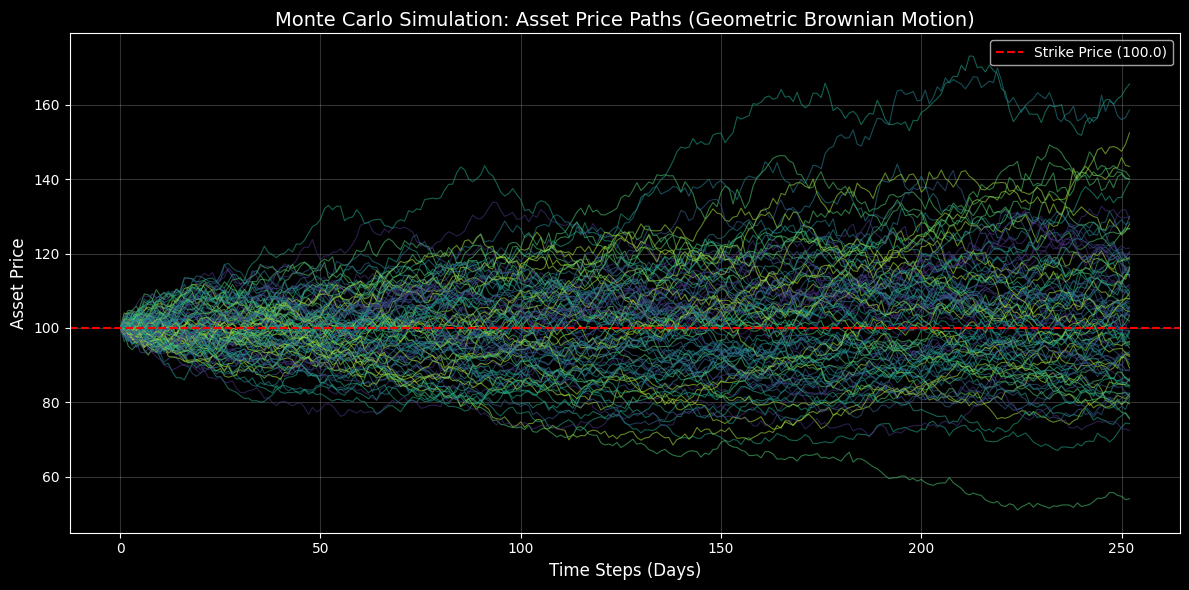

In [5]:
# เรียกใช้คลาส Visualization
viz = OptionVisualizer()

# 3.1 พล็อตกราฟ Monte Carlo Paths
viz.plot_simulation_paths(paths, params['K'])

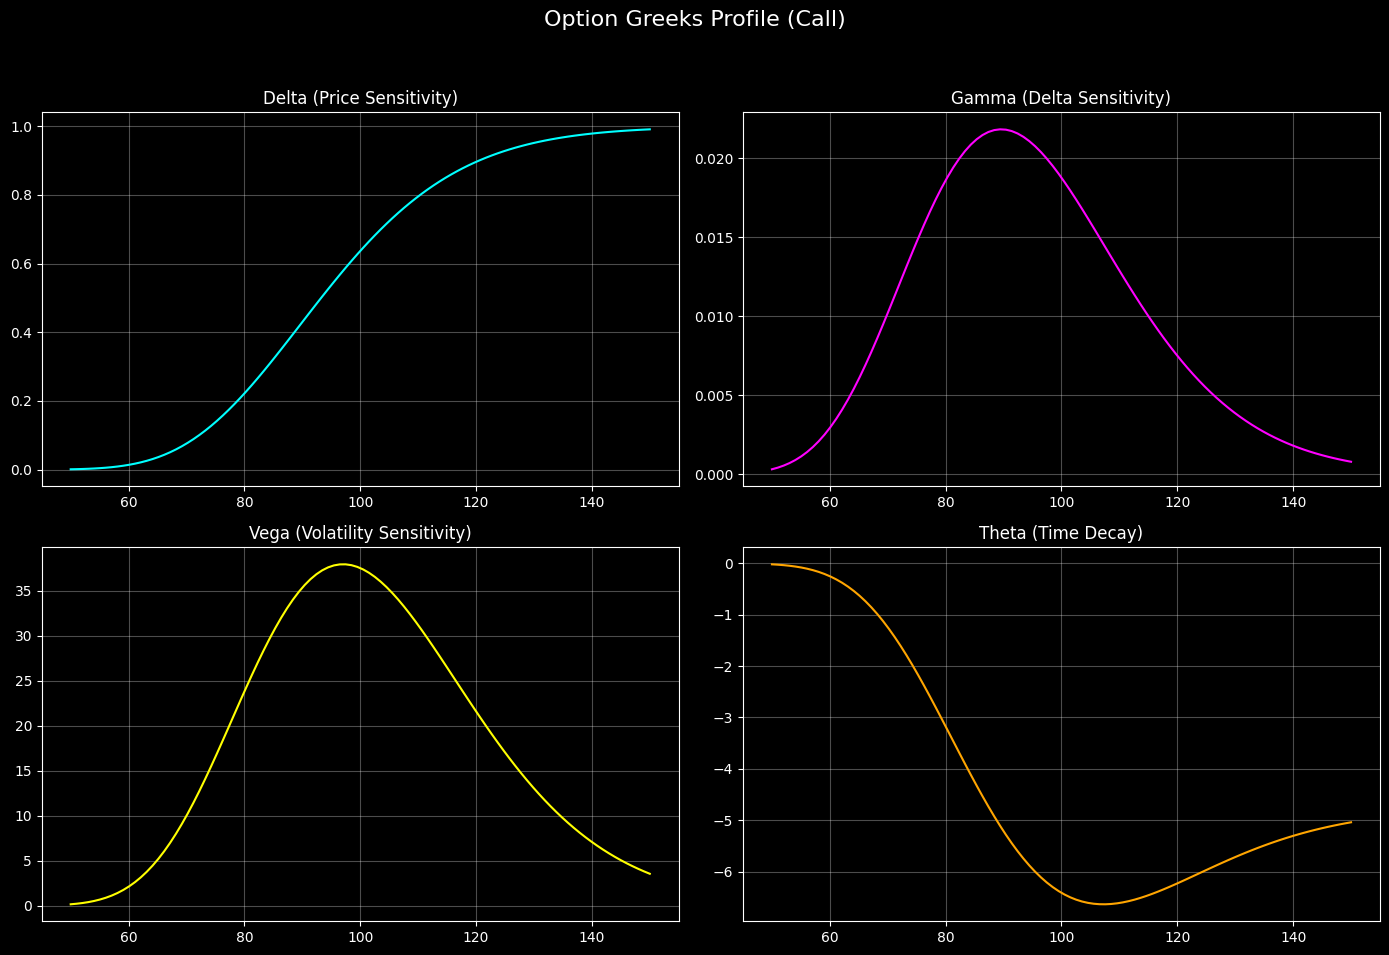

In [6]:
# 3.2 พล็อตกราฟ Option Greeks Profile (วิเคราะห์ Call Option)
S_range = np.linspace(50, 150, 100)
viz.plot_greeks_profile(BlackScholesPricer, S_range, K=params['K'], T=params['T'], r=params['r'], sigma=params['sigma'], option_type='call')

### 🎯 สรุปผลการทดลอง (Conclusion)
1. **Convergence:** ราคาจาก Monte Carlo Simulation ลู่เข้าใกล้ราคาทางทฤษฎีของ Black-Scholes มากเมื่อใช้จำนวนเส้นทางที่สูง (Law of Large Numbers)
2. **Greeks Behavior:** - **Delta** ของ Call Option วิ่งเข้าหา 1 เมื่อ In-the-money และเข้าใกล้ 0 เมื่อ Out-of-the-money
   - **Gamma** มีค่าสูงสุดที่บริเวณ At-the-money (S = K = 100) ซึ่งแสดงถึงความเสี่ยงที่ทิศทางราคาจะเปลี่ยนแปลงรุนแรงที่สุด
   - **Theta** เป็นค่าติดลบเสมอ เนื่องจากมูลค่าของเวลา (Time value) จะลดลงเรื่อยๆ เมื่อเข้าใกล้วันหมดอายุ